In [ ]:
# --- Cell A1: Mount Drive & set dataset paths (lab style) ---
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/My Drive/FER_project'   # change if your project folder is different

# Confirmed folder structure: each dataset has train/ and test/
JAFFE_TRAIN = BASE + '/data/JAFFE_raw/JAFFE/train'
JAFFE_TEST  = BASE + '/data/JAFFE_raw/JAFFE/test'
CK_TRAIN    = BASE + '/data/CK/train'
CK_TEST     = BASE + '/data/CK/test'

# make output folders if not exist
import os
os.makedirs(BASE + '/models', exist_ok=True)
os.makedirs(BASE + '/results', exist_ok=True)
os.makedirs(BASE + '/features', exist_ok=True)

print('Paths check:')
print(' JAFFE_TRAIN exists:', os.path.exists(JAFFE_TRAIN))
print(' JAFFE_TEST  exists:', os.path.exists(JAFFE_TEST))
print(' CK_TRAIN    exists:', os.path.exists(CK_TRAIN))
print(' CK_TEST     exists:', os.path.exists(CK_TEST))
print('BASE set to:', BASE)


Mounted at /content/drive
Paths check:
 JAFFE_TRAIN exists: True
 JAFFE_TEST  exists: True
 CK_TRAIN    exists: True
 CK_TEST     exists: True
BASE set to: /content/drive/My Drive/FER_project


In [ ]:

#imports: OpenCV, numpy, sklearn, plotting, joblib, etc.
import os, time, json, glob, joblib
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# sklearn imports used across training cells
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

print("Imports complete. cv2 version:", cv2.__version__)




Imports complete. cv2 version: 4.12.0


In [ ]:
# --- Local Binary Pattern (LBP) in lab style (no skimage) ---
# We implement basic uniform LBP P=8,R=1 style histogram (same idea as lab)
import numpy as np
import cv2

P = 8   # neighbours (fixed 8 for 3x3 neighbourhood)
R = 1   # radius (1 pixel)
LBP_NBINS = 256  # we'll use 256-bin histogram (0..255) as a clear lab baseline

def lbp_image_gray(img):
    """
    Compute basic 8-neighbour LBP image.
    Input:
      img - 2D uint8 grayscale image
    Output:
      lbp - 2D uint8 image of same size where each pixel = LBP code (0..255)
    Note: border pixels remain 0 (we iterate 1..h-2,1..w-2).
    """
    h, w = img.shape
    lbp = np.zeros((h, w), dtype=np.uint8)
    # Offsets for 8 neighbours (clockwise)
    offsets = [(-1,-1), (-1,0), (-1,1), (0,1), (1,1), (1,0), (1,-1), (0,-1)]
    for i in range(1, h-1):
        for j in range(1, w-1):
            c = int(img[i, j])
            code = 0
            # build 8-bit code
            for k, (dy, dx) in enumerate(offsets):
                nb = int(img[i + dy, j + dx])
                bit = 1 if nb >= c else 0
                code |= (bit << k)
            lbp[i, j] = code
    return lbp

def lbp_hist(img, nbins=LBP_NBINS, mask=None):
    """
    Compute normalized histogram of LBP codes.
    img: 2D uint8 LBP image (or original grayscale; we accept either).
    nbins: number of histogram bins (default 256)
    mask: optional boolean mask to include pixels
    returns: 1D float vector length nbins (sum -> 1.0)
    """
    if img.dtype != np.uint8:
        img_u8 = img.astype(np.uint8)
    else:
        img_u8 = img
    if mask is not None:
        hist = cv2.calcHist([img_u8], [0], mask.astype('uint8'), [nbins], [0, nbins]).flatten()
    else:
        hist = cv2.calcHist([img_u8], [0], None, [nbins], [0, nbins]).flatten()
    hist = hist.astype('float32')
    denom = hist.sum() + 1e-9
    hist /= denom
    return hist

# quick local test (small synthetic image) to verify functions behave
_test_img = np.zeros((8,8), dtype=np.uint8)
_test_img[3:5, 3:5] = 255
_lbp = lbp_image_gray(_test_img)
_hist = lbp_hist(_lbp)
print("LBP functions ready. Sample hist sum:", _hist.sum())

LBP functions ready. Sample hist sum: 1.0


In [ ]:
# -------------------------
# Cell A4: OpenCV HOG descriptor (lab style)
# -------------------------
import cv2
import numpy as np

# HOG parameters (matching lab examples)
WIN_SIZE = (64, 64)        # (width, height) for window / images
BLOCK_SIZE = (16, 16)
BLOCK_STRIDE = (8, 8)
CELL_SIZE = (8, 8)
NBINS = 9

# Create HOGDescriptor
hog = cv2.HOGDescriptor(WIN_SIZE, BLOCK_SIZE, BLOCK_STRIDE, CELL_SIZE, NBINS)

# Helper to compute HOG descriptor for a grayscale uint8 image
def hog_feature_opencv(img_uint8, win_size=WIN_SIZE):
    """
    img_uint8: 2D uint8 grayscale image (any size)
    Returns: 1D numpy array (HOG descriptor)
    """
    # ensure exact window size for HOG compute
    if img_uint8.shape != (win_size[1], win_size[0]):  # (h,w)
        img_resized = cv2.resize(img_uint8, win_size)
    else:
        img_resized = img_uint8
    descriptor = hog.compute(img_resized)   # returns Nx1 array
    return descriptor.flatten()

# Quick test: run HOG on a zero image to get descriptor length
_dummy = np.zeros((WIN_SIZE[1], WIN_SIZE[0]), dtype=np.uint8)
_dummy_desc = hog_feature_opencv(_dummy)
print("OpenCV HOG ready. Descriptor length:", _dummy_desc.shape[0])



OpenCV HOG ready. Descriptor length: 1764


In [ ]:
# --- Preprocess and load images into feature arrays (lab style loops) ---
import os
import numpy as np
from pathlib import Path
import cv2
import json

# Ensure BASE is set (from A1). If not, set it here:
# BASE = '/content/drive/MyDrive/FER_project'

# Image size used across pipeline (match HOG WIN_SIZE)
IMG_SIZE = (64, 64)   # (width, height)

def preprocess(path_or_img):
    """
    Read image path (or accept a 2D numpy array) -> grayscale -> resize -> equalize histogram.
    Returns uint8 numpy image of shape (h,w) where h=IMG_SIZE[1], w=IMG_SIZE[0].
    """
    if isinstance(path_or_img, str):
        img = cv2.imread(path_or_img, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Cannot read image: {path_or_img}")
    else:
        # assume numpy array (grayscale)
        img = path_or_img
    # resize to IMG_SIZE (cv2.resize takes (w,h))
    img_resized = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    # histogram equalization to reduce lighting variation
    img_eq = cv2.equalizeHist(img_resized)
    return img_eq

def build_features_from_split(root_folder, feature='lbp', save_prefix='jaffe_train'):
    """
    root_folder: folder with class subfolders (e.g. /.../JAFFE/train)
    feature: 'lbp' or 'hog'
    save_prefix: prefix for saved .npy files (e.g. 'jaffe_train')
    Returns: X (nxd), y (n), paths (n,)
    Side-effect: saves X, y, paths to BASE/features/<save_prefix>_<feature>_*.npy
    """
    X_list = []
    y_list = []
    p_list = []
    root = Path(root_folder)
    classes = sorted([d.name for d in root.iterdir() if d.is_dir()])
    if len(classes) == 0:
        raise FileNotFoundError(f"No class folders found in {root_folder}")
    print(f"Building '{feature}' features from: {root_folder}  Classes: {classes}")
    for cls in classes:
        cls_path = root / cls
        files = sorted(list(cls_path.glob('*')))
        for f in files:
            p = str(f)
            try:
                img = preprocess(p)   # returns uint8 2D image
                if feature == 'lbp':
                    # compute LBP image then histogram
                    lbp_img = lbp_image_gray(img)            # from A3
                    feat = lbp_hist(lbp_img, nbins=256)     # 256-bin normalized histogram
                elif feature == 'hog':
                    # compute HOG descriptor (OpenCV)
                    feat = hog_feature_opencv(img)          # from A4
                else:
                    raise ValueError("feature must be 'lbp' or 'hog'")
                X_list.append(feat)
                y_list.append(cls)
                p_list.append(p)
            except Exception as e:
                print("Skipping file:", p, "->", e)
    # convert to numpy arrays (X may be ragged if features lengths differ; HOG/LBP are fixed)
    X = np.array(X_list)
    y = np.array(y_list)
    paths = np.array(p_list)
    # Save arrays
    feat_dir = os.path.join(BASE, 'features')
    os.makedirs(feat_dir, exist_ok=True)
    np.save(os.path.join(feat_dir, f"{save_prefix}_{feature}_X.npy"), X)
    np.save(os.path.join(feat_dir, f"{save_prefix}_{feature}_y.npy"), y)
    np.save(os.path.join(feat_dir, f"{save_prefix}_{feature}_paths.npy"), paths)
    print(f"Saved features: {save_prefix}_{feature}_X.npy  shape={X.shape}")
    return X, y, paths

# Example: build all splits (run the specific calls below as needed)
# Uncomment one call at a time or run all in sequence.

# JAFFE train LBP
# X_j_train_lbp, y_j_train, p_j_train = build_features_from_split(JAFFE_TRAIN, 'lbp', 'jaffe_train')

# JAFFE test LBP
# X_j_test_lbp, y_j_test, p_j_test = build_features_from_split(JAFFE_TEST, 'lbp', 'jaffe_test')

# JAFFE train HOG
# X_j_train_hog, _, _ = build_features_from_split(JAFFE_TRAIN, 'hog', 'jaffe_train')

# JAFFE test HOG
# X_j_test_hog, _, _ = build_features_from_split(JAFFE_TEST, 'hog', 'jaffe_test')

# CK train HOG
# X_ck_tr_hog, y_ck_tr, p_ck_tr = build_features_from_split(CK_TRAIN, 'hog', 'ck_train')

# CK test HOG
# X_ck_te_hog, y_ck_te, p_ck_te = build_features_from_split(CK_TEST, 'hog', 'ck_test')

print("Cell A5 loaded. To build features, call build_features_from_split(...) for each split.")


Cell A5 loaded. To build features, call build_features_from_split(...) for each split.


In [ ]:
# -------------------------
# Run feature builds for the four splits (lab-style runner)
# -------------------------
# Make sure Cell A5 was executed successfully (build_features_from_split is available)

# 1) JAFFE train LBP
X_j_train_lbp, y_j_train, p_j_train = build_features_from_split(JAFFE_TRAIN, 'lbp', 'jaffe_train')
# 2) JAFFE test LBP
X_j_test_lbp, y_j_test, p_j_test = build_features_from_split(JAFFE_TEST, 'lbp', 'jaffe_test')

# 3) JAFFE train HOG
X_j_train_hog, y_j_train_hog, p_j_train_hog = build_features_from_split(JAFFE_TRAIN, 'hog', 'jaffe_train')
# 4) JAFFE test HOG
X_j_test_hog, y_j_test_hog, p_j_test_hog = build_features_from_split(JAFFE_TEST, 'hog', 'jaffe_test')

# 5) CK train HOG
X_ck_tr_hog, y_ck_tr, p_ck_tr = build_features_from_split(CK_TRAIN, 'hog', 'ck_train')
# 6) CK test HOG
X_ck_te_hog, y_ck_te, p_ck_te = build_features_from_split(CK_TEST, 'hog', 'ck_test')

print("\n--- Summary of shapes saved ---")
print("JAFFE train LBP X.shape:", X_j_train_lbp.shape, " y.shape:", y_j_train.shape)
print("JAFFE test  LBP X.shape:", X_j_test_lbp.shape, " y.shape:", y_j_test.shape)
print("JAFFE train HOG X.shape:", X_j_train_hog.shape, " y.shape:", y_j_train_hog.shape)
print("JAFFE test  HOG X.shape:", X_j_test_hog.shape, " y.shape:", y_j_test_hog.shape)
print("CK train   HOG X.shape:", X_ck_tr_hog.shape, " y.shape:", y_ck_tr.shape)
print("CK test    HOG X.shape:", X_ck_te_hog.shape, " y.shape:", y_ck_te.shape)

print("\nSaved .npy files in:", BASE + '/features')
print("If this cell crashes or is too slow, re-run the build one split at a time (uncomment only one call).")



Building 'lbp' features from: /content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/train  Classes: ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
Saved features: jaffe_train_lbp_X.npy  shape=(128, 256)
Building 'lbp' features from: /content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/test  Classes: ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
Saved features: jaffe_test_lbp_X.npy  shape=(55, 256)
Building 'hog' features from: /content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/train  Classes: ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
Saved features: jaffe_train_hog_X.npy  shape=(128, 1764)
Building 'hog' features from: /content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/test  Classes: ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
Saved features: jaffe_test_hog_X.npy  shape=(55, 1764)
Building 'hog' features from: /content/drive/My Drive/FER_project/data/CK/train  Classes: ['anger', 'fear', 'happy', 'neutral', 'sadness', '

In [ ]:
from collections import Counter
print("JAFFE train counts:", Counter(y_j_train))
print("JAFFE test counts :", Counter(y_j_test))
print("CK train counts   :", Counter(y_ck_tr))
print("CK test counts    :", Counter(y_ck_te))


JAFFE train counts: Counter({np.str_('Fear'): 22, np.str_('Happy'): 22, np.str_('Sad'): 22, np.str_('Neutral'): 21, np.str_('Surprise'): 21, np.str_('Angry'): 20})
JAFFE test counts : Counter({np.str_('Fear'): 10, np.str_('Angry'): 9, np.str_('Happy'): 9, np.str_('Neutral'): 9, np.str_('Sad'): 9, np.str_('Surprise'): 9})
CK train counts   : Counter({np.str_('neutral'): 86, np.str_('surprise'): 83, np.str_('happy'): 75, np.str_('sadness'): 41, np.str_('anger'): 40, np.str_('fear'): 16})
CK test counts    : Counter({np.str_('neutral'): 36, np.str_('surprise'): 35, np.str_('happy'): 30, np.str_('anger'): 18, np.str_('sadness'): 17, np.str_('fear'): 7})




=== Running experiment: JAFFE_LBP ===
[JAFFE_LBP] GridSearch SVM...
[JAFFE_LBP] SVM done in 3.8s. Best params: {'C': 10, 'gamma': 'scale'}
[JAFFE_LBP] SVM classification report:
               precision    recall  f1-score   support

       Angry       0.25      0.22      0.24         9
        Fear       0.18      0.50      0.26        10
       Happy       0.00      0.00      0.00         9
     Neutral       0.17      0.11      0.13         9
         Sad       0.18      0.22      0.20         9
    Surprise       0.00      0.00      0.00         9

    accuracy                           0.18        55
   macro avg       0.13      0.18      0.14        55
weighted avg       0.13      0.18      0.14        55



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


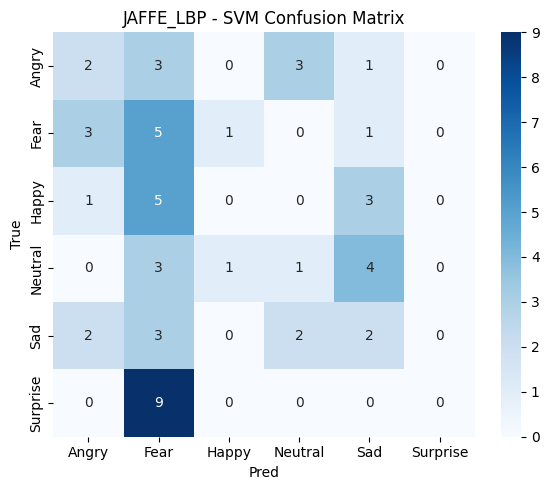

[JAFFE_LBP] GridSearch RandomForest...
[JAFFE_LBP] RF done in 5.8s. Best params: {'max_depth': None, 'n_estimators': 100}
[JAFFE_LBP] RF classification report:
               precision    recall  f1-score   support

       Angry       0.38      0.67      0.48         9
        Fear       0.27      0.30      0.29        10
       Happy       0.00      0.00      0.00         9
     Neutral       0.00      0.00      0.00         9
         Sad       0.17      0.22      0.19         9
    Surprise       0.00      0.00      0.00         9

    accuracy                           0.20        55
   macro avg       0.14      0.20      0.16        55
weighted avg       0.14      0.20      0.16        55



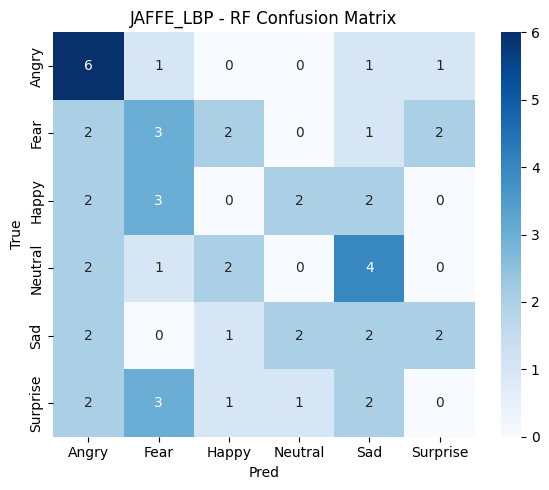

[JAFFE_LBP] Saved models and summary to /content/drive/My Drive/FER_project/models and /content/drive/My Drive/FER_project/results


=== Running experiment: JAFFE_HOG ===
[JAFFE_HOG] GridSearch SVM...
[JAFFE_HOG] SVM done in 0.6s. Best params: {'C': 10, 'gamma': 'scale'}
[JAFFE_HOG] SVM classification report:
               precision    recall  f1-score   support

       Angry       1.00      0.67      0.80         9
        Fear       0.29      1.00      0.45        10
       Happy       1.00      0.33      0.50         9
     Neutral       0.50      0.11      0.18         9
         Sad       0.33      0.22      0.27         9
    Surprise       1.00      0.44      0.62         9

    accuracy                           0.47        55
   macro avg       0.69      0.46      0.47        55
weighted avg       0.68      0.47      0.47        55



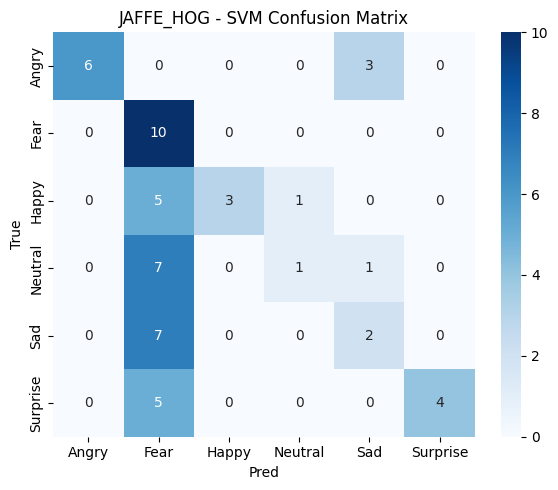

[JAFFE_HOG] GridSearch RandomForest...
[JAFFE_HOG] RF done in 12.6s. Best params: {'max_depth': None, 'n_estimators': 200}
[JAFFE_HOG] RF classification report:
               precision    recall  f1-score   support

       Angry       1.00      0.78      0.88         9
        Fear       0.36      0.50      0.42        10
       Happy       1.00      0.67      0.80         9
     Neutral       1.00      0.67      0.80         9
         Sad       0.38      0.56      0.45         9
    Surprise       0.78      0.78      0.78         9

    accuracy                           0.65        55
   macro avg       0.75      0.66      0.69        55
weighted avg       0.75      0.65      0.68        55



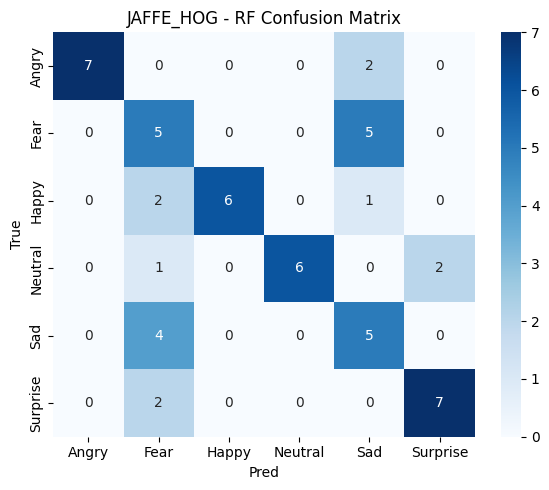

[JAFFE_HOG] Saved models and summary to /content/drive/My Drive/FER_project/models and /content/drive/My Drive/FER_project/results


=== Running experiment: CK_HOG ===
[CK_HOG] GridSearch SVM...
[CK_HOG] SVM done in 5.1s. Best params: {'C': 1, 'gamma': 'scale'}
[CK_HOG] SVM classification report:
               precision    recall  f1-score   support

       anger       0.47      0.39      0.42        18
        fear       0.00      0.00      0.00         7
       happy       1.00      0.87      0.93        30
     neutral       0.45      0.72      0.55        36
     sadness       0.53      0.47      0.50        17
    surprise       0.92      0.69      0.79        35

    accuracy                           0.64       143
   macro avg       0.56      0.52      0.53       143
weighted avg       0.67      0.64      0.64       143



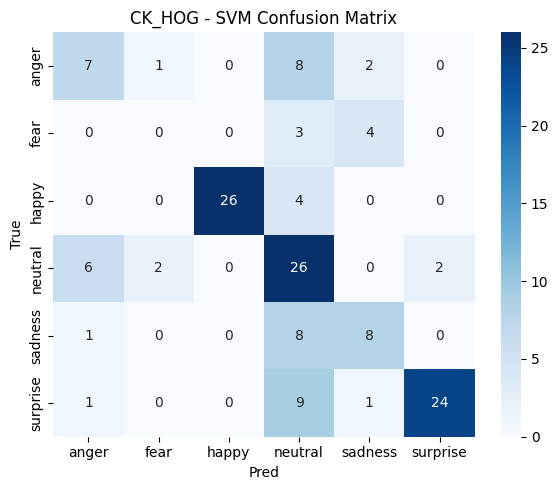

[CK_HOG] GridSearch RandomForest...
[CK_HOG] RF done in 28.7s. Best params: {'max_depth': 10, 'n_estimators': 200}
[CK_HOG] RF classification report:
               precision    recall  f1-score   support

       anger       0.75      0.33      0.46        18
        fear       0.00      0.00      0.00         7
       happy       0.87      0.87      0.87        30
     neutral       0.45      0.83      0.58        36
     sadness       0.50      0.29      0.37        17
    surprise       0.89      0.71      0.79        35

    accuracy                           0.64       143
   macro avg       0.58      0.51      0.51       143
weighted avg       0.67      0.64      0.62       143



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


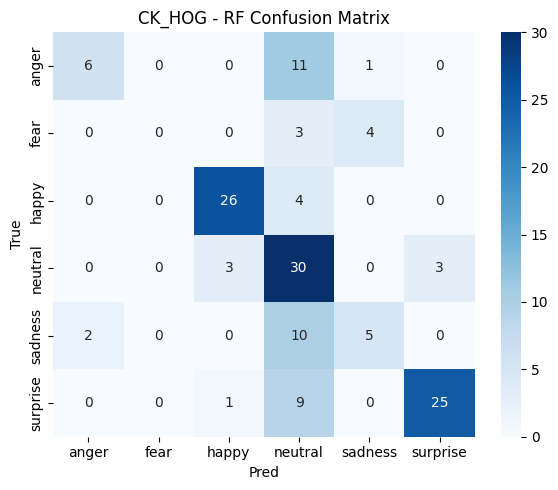

[CK_HOG] Saved models and summary to /content/drive/My Drive/FER_project/models and /content/drive/My Drive/FER_project/results

All experiments finished. Summaries saved to /content/drive/My Drive/FER_project/results


In [ ]:
# -------------------------
# Cell 7: Run experiments (JAFFE_LBP, JAFFE_HOG, CK_HOG) - lab style
# -------------------------
import os, time, json, joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# folders
RESULT_DIR = os.path.join(BASE, 'results')
MODEL_DIR  = os.path.join(BASE, 'models')
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# small grids (lab-style; fast)
svm_param_grid = {'C':[0.1, 1, 10], 'gamma':['scale', 0.01]}
rf_param_grid  = {'n_estimators':[100,200], 'max_depth':[None, 10]}

# helper to train & evaluate one experiment
def run_experiment(name, X_train, y_train, X_test, y_test):
    print("\n\n=== Running experiment:", name, "===")
    # 1) scale
    scaler = StandardScaler().fit(X_train)
    Xtr = scaler.transform(X_train)
    Xte = scaler.transform(X_test)
    # save scaler
    joblib.dump(scaler, os.path.join(MODEL_DIR, f"{name}_scaler.pkl"))
    # ---- SVM ----
    print(f"[{name}] GridSearch SVM...")
    svm = SVC(kernel='rbf', class_weight='balanced')
    gs = GridSearchCV(svm, svm_param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0)
    t0 = time.time()
    gs.fit(Xtr, y_train)
    print(f"[{name}] SVM done in {time.time()-t0:.1f}s. Best params: {gs.best_params_}")
    best_svm = gs.best_estimator_
    y_pred_svm = best_svm.predict(Xte)
    print(f"[{name}] SVM classification report:\n", classification_report(y_test, y_pred_svm))
    # confusion matrix
    cm = confusion_matrix(y_test, y_pred_svm, labels=best_svm.classes_)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=best_svm.classes_, yticklabels=best_svm.classes_, cmap='Blues')
    plt.title(f"{name} - SVM Confusion Matrix"); plt.xlabel('Pred'); plt.ylabel('True')
    fname = os.path.join(RESULT_DIR, f"{name}_svm_confusion.png")
    plt.tight_layout(); plt.savefig(fname, dpi=200); plt.show()
    # save model
    joblib.dump(best_svm, os.path.join(MODEL_DIR, f"{name}_svm.pkl"))
    # metrics
    svm_metrics = {
        'accuracy': float(accuracy_score(y_test, y_pred_svm)),
        'f1_macro': float(f1_score(y_test, y_pred_svm, average='macro'))
    }

    # ---- Random Forest ----
    print(f"[{name}] GridSearch RandomForest...")
    rf = RandomForestClassifier(class_weight='balanced', random_state=42)
    gs_rf = GridSearchCV(rf, rf_param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0)
    t0 = time.time()
    gs_rf.fit(Xtr, y_train)
    print(f"[{name}] RF done in {time.time()-t0:.1f}s. Best params: {gs_rf.best_params_}")
    best_rf = gs_rf.best_estimator_
    y_pred_rf = best_rf.predict(Xte)
    print(f"[{name}] RF classification report:\n", classification_report(y_test, y_pred_rf))
    cm2 = confusion_matrix(y_test, y_pred_rf, labels=best_rf.classes_)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm2, annot=True, fmt='d', xticklabels=best_rf.classes_, yticklabels=best_rf.classes_, cmap='Blues')
    plt.title(f"{name} - RF Confusion Matrix"); plt.xlabel('Pred'); plt.ylabel('True')
    fname2 = os.path.join(RESULT_DIR, f"{name}_rf_confusion.png")
    plt.tight_layout(); plt.savefig(fname2, dpi=200); plt.show()
    joblib.dump(best_rf, os.path.join(MODEL_DIR, f"{name}_rf.pkl"))
    rf_metrics = {
        'accuracy': float(accuracy_score(y_test, y_pred_rf)),
        'f1_macro': float(f1_score(y_test, y_pred_rf, average='macro'))
    }

    # Save per-experiment summary
    summary = {
        'svm': {'best_params': gs.best_params_, 'metrics': svm_metrics},
        'rf':  {'best_params': gs_rf.best_params_, 'metrics': rf_metrics}
    }
    with open(os.path.join(RESULT_DIR, f"{name}_summary.json"), 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"[{name}] Saved models and summary to {MODEL_DIR} and {RESULT_DIR}")

    return summary

# Run experiments one by one (will raise NameError if variable missing)
results_all = {}
# JAFFE LBP
results_all['JAFFE_LBP'] = run_experiment('JAFFE_LBP', X_j_train_lbp, y_j_train, X_j_test_lbp, y_j_test)
# JAFFE HOG
results_all['JAFFE_HOG'] = run_experiment('JAFFE_HOG', X_j_train_hog, y_j_train_hog, X_j_test_hog, y_j_test_hog)
# CK HOG
results_all['CK_HOG'] = run_experiment('CK_HOG', X_ck_tr_hog, y_ck_tr, X_ck_te_hog, y_ck_te)

# Save a consolidated summary CSV/JSON
with open(os.path.join(RESULT_DIR, 'all_experiments_summary.json'), 'w') as f:
    json.dump(results_all, f, indent=2)

print("\nAll experiments finished. Summaries saved to", RESULT_DIR)



In [ ]:
# List a few files from each JAFFE test subfolder so you can copy exact names
import os, glob
BASE = '/content/drive/MyDrive/FER_project'   # use your BASE from A1
JAFFE_TEST = os.path.join(BASE, 'data', 'JAFFE_raw','JAFFE', 'test')

for cls in sorted(os.listdir(JAFFE_TEST)):
    cls_dir = os.path.join(JAFFE_TEST, cls)
    if not os.path.isdir(cls_dir):
        continue
    files = sorted(glob.glob(os.path.join(cls_dir, '*')))
    print(f"Class: {cls} -> {len(files)} files; sample files:")
    for f in files[:5]:
        print("  ", f)
    print()


Class: Angry -> 9 files; sample files:
   /content/drive/MyDrive/FER_project/data/JAFFE_raw/JAFFE/test/Angry/TM.AN1.190.tiff
   /content/drive/MyDrive/FER_project/data/JAFFE_raw/JAFFE/test/Angry/TM.AN2.191.tiff
   /content/drive/MyDrive/FER_project/data/JAFFE_raw/JAFFE/test/Angry/TM.AN3.192.tiff
   /content/drive/MyDrive/FER_project/data/JAFFE_raw/JAFFE/test/Angry/UY.AN1.146.tiff
   /content/drive/MyDrive/FER_project/data/JAFFE_raw/JAFFE/test/Angry/UY.AN2.147.tiff

Class: Fear -> 10 files; sample files:
   /content/drive/MyDrive/FER_project/data/JAFFE_raw/JAFFE/test/Fear/TM.FE1.196.tiff
   /content/drive/MyDrive/FER_project/data/JAFFE_raw/JAFFE/test/Fear/TM.FE2.197.tiff
   /content/drive/MyDrive/FER_project/data/JAFFE_raw/JAFFE/test/Fear/TM.FE3.198.tiff
   /content/drive/MyDrive/FER_project/data/JAFFE_raw/JAFFE/test/Fear/UY.FE1.152.tiff
   /content/drive/MyDrive/FER_project/data/JAFFE_raw/JAFFE/test/Fear/UY.FE2.153.tiff

Class: Happy -> 9 files; sample files:
   /content/drive/MyDrive/

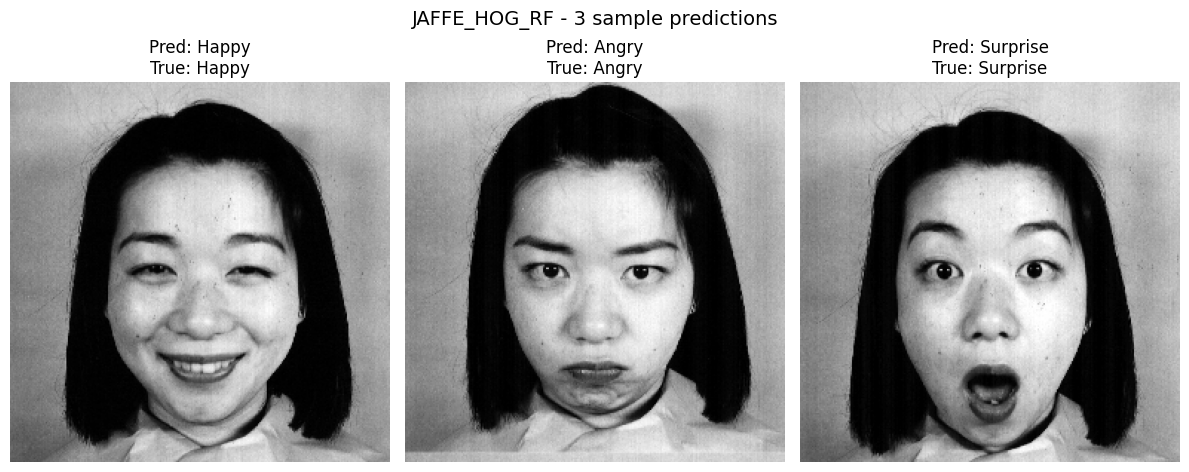

Predictions: ['Happy' 'Angry' 'Surprise']
Saved figure to: /content/drive/My Drive/FER_project/results/jaffe_3face_predictions_improved.png


In [ ]:
import os
import joblib
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Uncomment this if running in a Jupyter notebook
# %matplotlib inline

# ------------------- CONFIG -------------------
# Update BASE to your project root (same as before)
BASE = '/content/drive/My Drive/FER_project'   # <- change if needed

MODEL_PATH = os.path.join(BASE, 'models', 'JAFFE_HOG_rf.pkl')       # trained model path
SCALER_PATH = os.path.join(BASE, 'models', 'JAFFE_HOG_scaler.pkl') # scaler path (optional)
RESULT_DIR = os.path.join(BASE, 'results')
os.makedirs(RESULT_DIR, exist_ok=True)

# Example image list (replace with your own)
image_paths = [
    '/content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/test/Happy/YM.HA2.53.tiff',
    '/content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/test/Angry/YM.AN1.61.tiff',
    '/content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/test/Surprise/YM.SU1.58.tiff'
]

true_labels = ['Happy', 'Angry', 'Surprise']  # optional: keep or set to None

# ------------------- HOG SETTINGS -------------------
# These must match whatever you used during training.
WIN_SIZE = (64, 64)             # (width, height) used by cv2.HOGDescriptor
BLOCK_SIZE = (16, 16)
BLOCK_STRIDE = (8, 8)
CELL_SIZE = (8, 8)
NBINS = 9

hog = cv2.HOGDescriptor(WIN_SIZE, BLOCK_SIZE, BLOCK_STRIDE, CELL_SIZE, NBINS)

# ------------------- HELPERS -------------------
def read_image_grayscale(path):
    """Read raw grayscale image (keep original resolution for display)."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    return img

def preprocess_for_hog(img_uint8, apply_clahe=True, target_size=WIN_SIZE):
    """
    Prepare an image for HOG:
      - optionally apply CLAHE (better local contrast)
      - resize to WIN_SIZE with INTER_CUBIC (sharp)
      - return uint8 image
    Note: This does NOT overwrite or replace the original image used for plotting.
    """
    im = img_uint8.copy()
    # apply CLAHE to boost local contrast (helpful for small facial details)
    if apply_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        im = clahe.apply(im)

    # Resize to HOG window using bicubic interpolation for less blur
    if (im.shape[1], im.shape[0]) != (target_size[0], target_size[1]):
        im = cv2.resize(im, target_size, interpolation=cv2.INTER_CUBIC)

    # ensure uint8
    im = im.astype(np.uint8)
    return im

def hog_feature_for_model(img_uint8):
    """Compute HOG descriptor flatten vector (expects uint8 image sized to WIN_SIZE)."""
    # If the image is not exactly WIN_SIZE, resize here (defensive)
    if (img_uint8.shape[1], img_uint8.shape[0]) != (WIN_SIZE[0], WIN_SIZE[1]):
        img_uint8 = cv2.resize(img_uint8, WIN_SIZE, interpolation=cv2.INTER_CUBIC)
    desc = hog.compute(img_uint8)
    return desc.flatten()

# ------------------- LOAD MODEL & SCALER -------------------
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}. Check file name and path.")
model = joblib.load(MODEL_PATH)

scaler = None
if os.path.exists(SCALER_PATH):
    try:
        scaler = joblib.load(SCALER_PATH)
    except Exception as e:
        print("Warning: could not load scaler:", e)
        scaler = None
else:
    print("Note: scaler file not found; proceeding without scaling (not recommended).")

# ------------------- PROCESS & PREDICT -------------------
loaded_originals = []   # raw images (for display)
hog_features = []
failed_indices = []

for idx, p in enumerate(image_paths):
    try:
        raw = read_image_grayscale(p)
        loaded_originals.append(raw)

        pre = preprocess_for_hog(raw, apply_clahe=True, target_size=WIN_SIZE)
        feat = hog_feature_for_model(pre)
        hog_features.append(feat)
    except Exception as e:
        print(f"Error for {p}: {e}")
        # append placeholders to keep indexing consistent
        loaded_originals.append(np.zeros((64,64), dtype=np.uint8))
        feat_shape = hog.compute(np.zeros((WIN_SIZE[1], WIN_SIZE[0]), dtype=np.uint8)).shape
        hog_features.append(np.zeros(feat_shape).flatten())
        failed_indices.append(idx)

X = np.vstack(hog_features).astype('float32')

if scaler is not None:
    try:
        Xs = scaler.transform(X)
    except Exception as e:
        print("Scaler transform failed:", e)
        Xs = X
else:
    Xs = X

preds = model.predict(Xs)

# ------------------- DISPLAY & SAVE -------------------
n = len(image_paths)
fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
if n == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.imshow(loaded_originals[i], cmap='gray', vmin=0, vmax=255)
    title = f"Pred: {preds[i]}"
    if true_labels and i < len(true_labels):
        title += f"\nTrue: {true_labels[i]}"
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle('JAFFE_HOG_RF - 3 sample predictions', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

out_path = os.path.join(RESULT_DIR, 'jaffe_3face_predictions_improved.png')
plt.savefig(out_path, dpi=300)   # higher dpi for crisper saved image
plt.show()

print("Predictions:", preds)
print("Saved figure to:", out_path)
if failed_indices:
    print("Failed indices:", failed_indices)


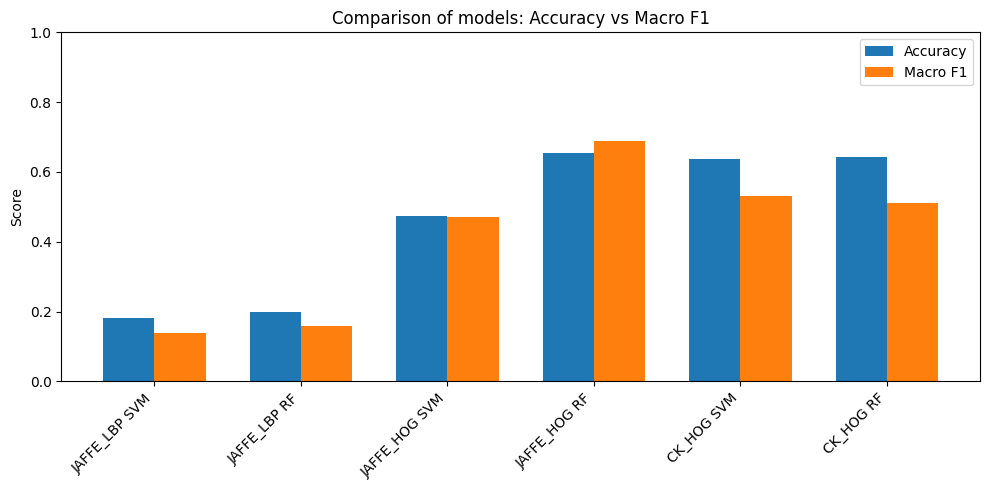

Saved chart to: /content/drive/My Drive/FER_project/results/models_comparison_accuracy_f1.png


In [ ]:
# -------------------------
# Plot comparison of Accuracies and Macro-F1 for all experiments
# -------------------------
import os, json, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

RESULT_DIR = os.path.join(BASE, 'results')

# load the consolidated summary if present
summary_path = os.path.join(RESULT_DIR, 'all_experiments_summary.json')
if os.path.exists(summary_path):
    with open(summary_path, 'r') as f:
        results_all = json.load(f)
else:
    # try to build results_all from per-experiment files saved earlier
    results_all = {}
    for name in ['JAFFE_LBP','JAFFE_HOG','CK_HOG']:
        p = os.path.join(RESULT_DIR, f"{name}_summary.json")
        if os.path.exists(p):
            with open(p,'r') as f:
                results_all[name] = json.load(f)
        else:
            print("Warning: missing summary for", name)

# Prepare data for plotting
labels = []
accs = []
f1s = []
for name, info in results_all.items():
    labels.append(name + " SVM")
    accs.append(info['svm']['metrics']['accuracy'])
    f1s.append(info['svm']['metrics']['f1_macro'])
    labels.append(name + " RF")
    accs.append(info['rf']['metrics']['accuracy'])
    f1s.append(info['rf']['metrics']['f1_macro'])

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - w/2, accs, width=w, label='Accuracy')
plt.bar(x + w/2, f1s, width=w, label='Macro F1')
plt.xticks(x, labels, rotation=45, ha='right')
plt.ylabel('Score')
plt.ylim(0,1.0)
plt.title('Comparison of models: Accuracy vs Macro F1')
plt.legend()
plt.tight_layout()
out_chart = os.path.join(RESULT_DIR, 'models_comparison_accuracy_f1.png')
plt.savefig(out_chart, dpi=200)
plt.show()
print("Saved chart to:", out_chart)


In [ ]:
# -------------------------
# Export a clean results table (CSV + JSON) for report (lab-style)
# -------------------------
import os, json, csv, pandas as pd

RESULT_DIR = os.path.join(BASE, 'results')
MODEL_DIR  = os.path.join(BASE, 'models')

# experiments we ran (same canonical names as Cell 7)
experiment_names = ['JAFFE_LBP', 'JAFFE_HOG', 'CK_HOG']

rows = []
for exp in experiment_names:
    summary_file = os.path.join(RESULT_DIR, f"{exp}_summary.json")
    svm_model = os.path.join(MODEL_DIR, f"{exp}_svm.pkl")
    rf_model  = os.path.join(MODEL_DIR, f"{exp}_rf.pkl")
    svm_cm = os.path.join(RESULT_DIR, f"{exp}_svm_confusion.png")
    rf_cm  = os.path.join(RESULT_DIR, f"{exp}_rf_confusion.png")
    if not os.path.exists(summary_file):
        print(f"Warning: missing summary file for {exp}: {summary_file} (skipping)")
        continue
    with open(summary_file, 'r') as f:
        s = json.load(f)
    # add SVM row
    rows.append({
        'experiment': exp,
        'classifier': 'SVM',
        'accuracy': s['svm']['metrics']['accuracy'],
        'macro_f1': s['svm']['metrics']['f1_macro'],
        'best_params': json.dumps(s['svm']['best_params']),
        'model_path': svm_model if os.path.exists(svm_model) else '',
        'confusion_matrix_path': svm_cm if os.path.exists(svm_cm) else '',
        'report_path': os.path.join(RESULT_DIR, f"{exp}_svm_classification_report.txt") if os.path.exists(os.path.join(RESULT_DIR, f"{exp}_svm_classification_report.txt")) else ''
    })
    # add RF row
    rows.append({
        'experiment': exp,
        'classifier': 'RandomForest',
        'accuracy': s['rf']['metrics']['accuracy'],
        'macro_f1': s['rf']['metrics']['f1_macro'],
        'best_params': json.dumps(s['rf']['best_params']),
        'model_path': rf_model if os.path.exists(rf_model) else '',
        'confusion_matrix_path': rf_cm if os.path.exists(rf_cm) else '',
        'report_path': os.path.join(RESULT_DIR, f"{exp}_rf_classification_report.txt") if os.path.exists(os.path.join(RESULT_DIR, f"{exp}_rf_classification_report.txt")) else ''
    })

# Create dataframe
df = pd.DataFrame(rows, columns=['experiment','classifier','accuracy','macro_f1','best_params','model_path','confusion_matrix_path','report_path'])

# Save CSV + pretty JSON
csv_path = os.path.join(RESULT_DIR, 'results_table.csv')
json_path = os.path.join(RESULT_DIR, 'results_table.json')
df.to_csv(csv_path, index=False)
with open(json_path, 'w') as f:
    json.dump(rows, f, indent=2)

# Display result in notebook (interactive table)
try:
    import ace_tools as tools
    tools.display_dataframe_to_user("Results Table", df)
except Exception:
    display(df)

print("Saved CSV:", csv_path)
print("Saved JSON:", json_path)


,experiment,classifier,accuracy,macro_f1,best_params,model_path,confusion_matrix_path,report_path
0,JAFFE_LBP,SVM,0.181818,0.138631,"{""C"": 10, ""gamma"": ""scale""}",/content/drive/My Drive/FER_project/models/JAF...,/content/drive/My Drive/FER_project/results/JA...,
1,JAFFE_LBP,RandomForest,0.200000,0.159365,"{""max_depth"": null, ""n_estimators"": 100}",/content/drive/My Drive/FER_project/models/JAF...,/content/drive/My Drive/FER_project/results/JA...,
2,JAFFE_HOG,SVM,0.472727,0.469736,"{""C"": 10, ""gamma"": ""scale""}",/content/drive/My Drive/FER_project/models/JAF...,/content/drive/My Drive/FER_project/results/JA...,
3,JAFFE_HOG,RandomForest,0.654545,0.687332,"{""max_depth"": null, ""n_estimators"": 200}",/content/drive/My Drive/FER_project/models/JAF...,/content/drive/My Drive/FER_project/results/JA...,
4,CK_HOG,SVM,0.636364,0.532148,"{""C"": 1, ""gamma"": ""scale""}",/content/drive/My Drive/FER_project/models/CK_...,/content/drive/My Drive/FER_project/results/CK...,
5,CK_HOG,RandomForest,0.643357,0.512458,"{""max_depth"": 10, ""n_estimators"": 200}",/content/drive/My Drive/FER_project/models/CK_...,/content/drive/My Drive/FER_project/results/CK...,


Saved CSV: /content/drive/My Drive/FER_project/results/results_table.csv
Saved JSON: /content/drive/My Drive/FER_project/results/results_table.json


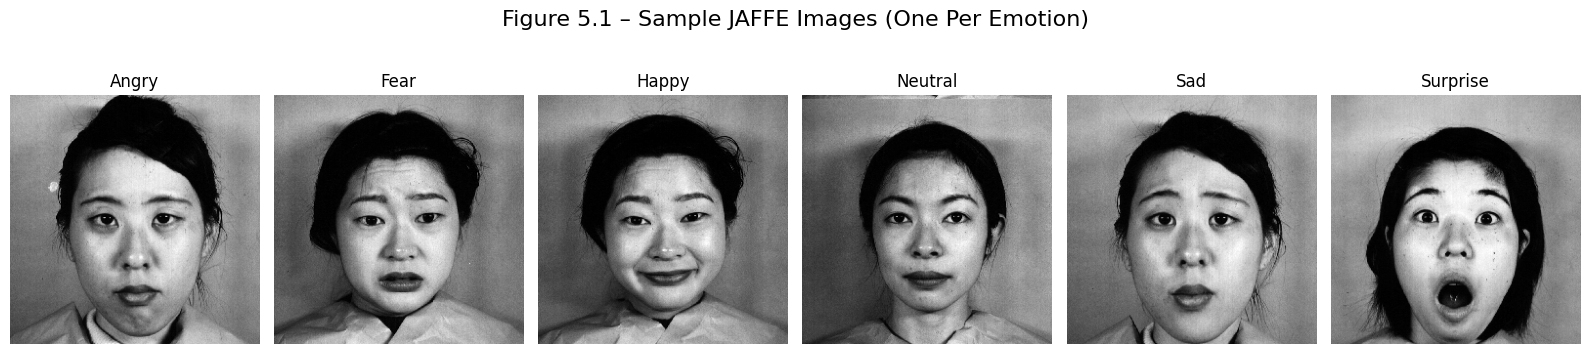

Saved figure to: /content/drive/My Drive/FER_project/results/Figure_5_1_JAFFE_samples.png


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# ----------------------------
# PATHS
# ----------------------------
base_path = "/content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/train"
save_path = "/content/drive/My Drive/FER_project/results/Figure_5_1_JAFFE_samples.png"

# Emotion folder names (adjust if your folder names differ)
emotions = ["Angry", "Fear", "Happy", "Neutral", "Sad", "Surprise"]

sample_images = []

# ----------------------------
# SELECT ONE IMAGE PER EMOTION
# ----------------------------
for emo in emotions:
    emo_dir = os.path.join(base_path, emo)

    if not os.path.exists(emo_dir):
        print(f"Folder missing: {emo_dir}")
        continue

    # List all images in the folder
    files = [f for f in os.listdir(emo_dir) if f.lower().endswith(('.png','.jpg','.jpeg','.tiff'))]

    if len(files) == 0:
        print(f"No images found in {emo_dir}")
        continue

    # Pick the first image
    img_path = os.path.join(emo_dir, files[0])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        sample_images.append((emo, img))
    else:
        print(f"Could not load: {img_path}")

# ----------------------------
# PLOT IMAGES
# ----------------------------
plt.figure(figsize=(16, 4))

for i, (label, img) in enumerate(sample_images):
    plt.subplot(1, len(sample_images), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(label, fontsize=12)
    plt.axis('off')

plt.suptitle("Figure 5.1 – Sample JAFFE Images (One Per Emotion)", fontsize=16)
plt.tight_layout()

# ----------------------------
# SAVE FIGURE
# ----------------------------
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved figure to:", save_path)


Using CK base folder: /content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/test


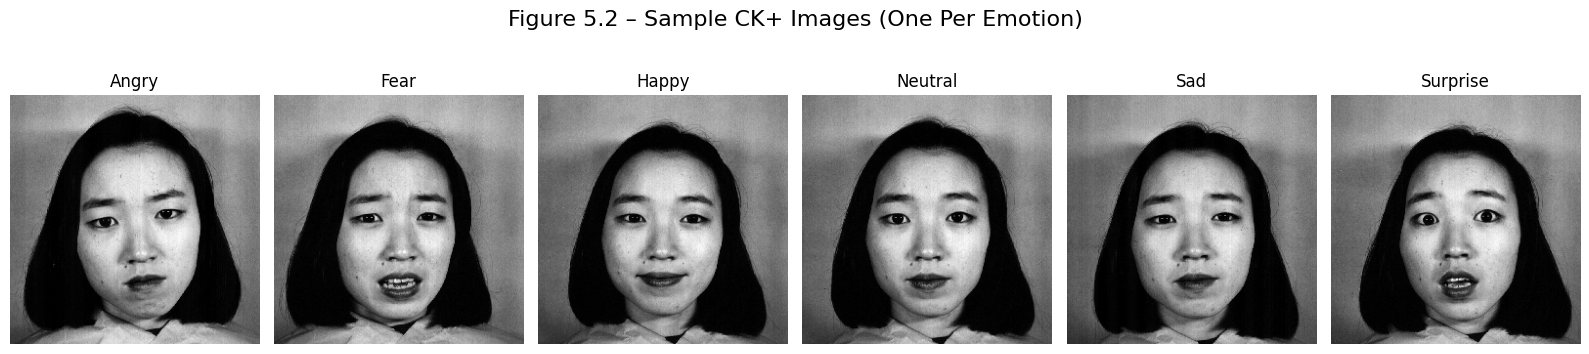

Saved figure to: /content/drive/My Drive/FER_project/results/Figure_5_2_CK_samples.png


In [ ]:
# Figure 5.2 - CK+ sample images
import os
import cv2
import matplotlib.pyplot as plt

# ---------- ADJUSTABLE: safe default results path ----------
results_dir = "/content/drive/My Drive/FER_project/results"
os.makedirs(results_dir, exist_ok=True)
save_path = os.path.join(results_dir, "Figure_5_2_CK_samples.png")

# ---------- Emotion labels (keep same order as JAFFE) ----------
emotions = ["Angry", "Fear", "Happy", "Neutral", "Sad", "Surprise"]

# ---------- Helper: candidate CK folder names to try ----------
candidates = [
    "/content/drive/My Drive/FER_project/data/CK",
    "/content/drive/My Drive/FER_project/data/CK+",
    "/content/drive/My Drive/FER_project/data/CK_raw",
    "/content/drive/My Drive/FER_project/data/CK+_raw",
    "/content/drive/My Drive/FER_project/data/Cohn-Kanade",
    "/content/drive/My Drive/FER_project/data/Cohn-Kanade+",
    "/content/drive/My Drive/FER_project/data/CK+/train",
    "/content/drive/My Drive/FER_project/data/CK+/test",
    "/content/drive/My Drive/FER_project/data/CK/train",
    "/content/drive/My Drive/FER_project/data/CK/test",
    "/content/drive/My Drive/FER_project/data/CK_raw/CK+",
]

# ---------- FIND a folder that contains emotion subfolders ----------
found_base = None
for cand in candidates:
    if os.path.isdir(cand):
        # check if cand contains emotion folders
        has_emotions = all(os.path.isdir(os.path.join(cand, e)) for e in emotions)
        if has_emotions:
            found_base = cand
            break

# If not found above, try a wider recursive search under the FER_project/data folder
if found_base is None:
    search_root = "/content/drive/My Drive/FER_project/data"
    if os.path.isdir(search_root):
        for root, dirs, files in os.walk(search_root):
            # check if current root contains emotion-named directories
            if all(os.path.isdir(os.path.join(root, e)) for e in emotions):
                found_base = root
                break

# If still not found, try common CK+ structure where images are inside subject/emotion folders
# We'll attempt to find image files that contain each emotion name in their parent path
if found_base is None:
    # fallback: find any directory that contains images and try to pull images by scanning filenames
    fallback_root = "/content/drive/My Drive/FER_project/data"
    if os.path.isdir(fallback_root):
        # just mark fallback; we'll search images by scanning file paths for emotion keywords
        found_base = None

# ---------- Collect one sample image per emotion ----------
sample_images = []

def pick_image_from_dir(dpath):
    files = [f for f in os.listdir(dpath) if f.lower().endswith(('.png','.jpg','.jpeg','.tiff','.bmp'))]
    if not files:
        return None
    # prefer a file that doesn't look like athumb name; pick first real image
    files.sort()
    for fname in files:
        p = os.path.join(dpath, fname)
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            return img
    return None

if found_base:
    print("Using CK base folder:", found_base)
    for emo in emotions:
        emo_dir = os.path.join(found_base, emo)
        img = None
        if os.path.isdir(emo_dir):
            img = pick_image_from_dir(emo_dir)
        else:
            # try case-insensitive match
            subdirs = [d for d in os.listdir(found_base) if d.lower() == emo.lower()]
            if subdirs:
                img = pick_image_from_dir(os.path.join(found_base, subdirs[0]))
        if img is not None:
            sample_images.append((emo, img))
        else:
            print(f"Warning: no image found for emotion folder: {emo} under {found_base}")
else:
    # fallback scan: try to find files whose parent folder contains the emotion name
    print("No direct CK folder structure found — doing fallback scan for images")
    base_scan = "/content/drive/My Drive/FER_project/data"
    found = {e: None for e in emotions}
    for root, dirs, files in os.walk(base_scan):
        for f in files:
            if not f.lower().endswith(('.png','.jpg','.jpeg','.tiff','.bmp')):
                continue
            lower_root = root.lower()
            for emo in emotions:
                if emo.lower() in lower_root and found[emo] is None:
                    p = os.path.join(root, f)
                    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        found[emo] = img
        # small speed-up: break if all found
        if all(found[e] is not None for e in emotions):
            break
    for emo in emotions:
        if found[emo] is not None:
            sample_images.append((emo, found[emo]))
        else:
            print(f"Fallback: no sample found for {emo}")

# ---------- If still empty, error message ----------
if len(sample_images) == 0:
    raise FileNotFoundError("No CK+ sample images found. Please check your dataset path(s).")

# ---------- PLOT & SAVE ----------
plt.figure(figsize=(16, 4))
for i, (label, img) in enumerate(sample_images):
    plt.subplot(1, len(sample_images), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(label, fontsize=12)
    plt.axis('off')

plt.suptitle("Figure 5.2 – Sample CK+ Images (One Per Emotion)", fontsize=16)
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved figure to:", save_path)


Using image: /content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/train/Angry/NM.AN2.105.tiff


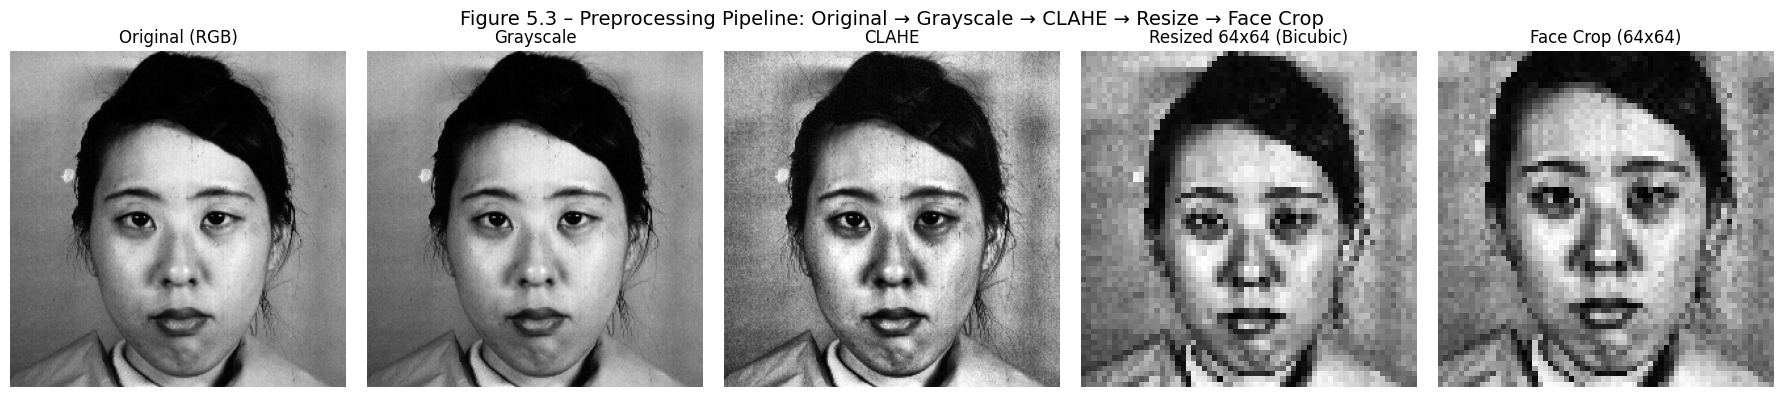

Saved preprocessing figure to: /content/drive/My Drive/FER_project/results/Figure_5_3_Preprocessing.png


In [ ]:
# Figure 5.3 - Preprocessing pipeline visualization
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- Paths ----------
jaffe_train = "/content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/train"
ck_candidates = [
    "/content/drive/My Drive/FER_project/data/CK",
    "/content/drive/My Drive/FER_project/data/CK+",
    "/content/drive/My Drive/FER_project/data/CK_raw",
]
results_dir = "/content/drive/My Drive/FER_project/results"
os.makedirs(results_dir, exist_ok=True)
save_path = os.path.join(results_dir, "Figure_5_3_Preprocessing.png")

# ---------- Helper: find one image ----------
def find_first_image_in_dir(root_dir):
    if not os.path.isdir(root_dir):
        return None
    # Walk depth-first until find an image file
    for root, dirs, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith(('.png','.jpg','.jpeg','.tiff','.bmp')):
                return os.path.join(root, f)
    return None

img_path = find_first_image_in_dir(jaffe_train)
if img_path is None:
    # try ck candidates
    for cand in ck_candidates:
        img_path = find_first_image_in_dir(cand)
        if img_path:
            break

if img_path is None:
    raise FileNotFoundError("No sample image found in JAFFE train or CK candidate folders. Update the path.")

print("Using image:", img_path)

# ---------- Read image ----------
img_color = cv2.imread(img_path, cv2.IMREAD_COLOR)  # BGR
if img_color is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

# Convert BGR->RGB for plotting color
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
# Grayscale
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# ---------- CLAHE ----------
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img_gray)

# ---------- Resize (bicubic) to 64x64 ----------
target_size = (64, 64)
img_resized = cv2.resize(img_clahe, target_size, interpolation=cv2.INTER_CUBIC)

# ---------- Haar Cascade face detection (crop) ----------
# Use OpenCV's default frontal face classifier. If not present, fallback to resized image.
face_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_crop = None
if os.path.exists(face_cascade_path):
    face_cascade = cv2.CascadeClassifier(face_cascade_path)
    # Detect on the CLAHE image (better contrast)
    faces = face_cascade.detectMultiScale(img_clahe, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))
    if len(faces) > 0:
        # pick largest face
        faces = sorted(faces, key=lambda r: r[2]*r[3], reverse=True)
        x,y,w,h = faces[0]
        # expand a bit for margin
        pad = int(0.15 * max(w,h))
        x0 = max(0, x-pad)
        y0 = max(0, y-pad)
        x1 = min(img_clahe.shape[1], x+w+pad)
        y1 = min(img_clahe.shape[0], y+h+pad)
        face_roi = img_clahe[y0:y1, x0:x1]
        # resize face crop to 64x64 for consistent display
        face_crop = cv2.resize(face_roi, target_size, interpolation=cv2.INTER_CUBIC)
    else:
        print("Haar cascade ran but found no faces; face crop will fallback to resized image.")
else:
    print("Haar cascade xml not found; skipping face detection.")

if face_crop is None:
    face_crop = img_resized.copy()

# ---------- Prepare display panels ----------
panels = [
    ("Original (RGB)", img_rgb if img_rgb is not None else cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)),
    ("Grayscale", cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)),
    ("CLAHE", cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)),
    ("Resized 64x64 (Bicubic)", cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)),
    ("Face Crop (64x64)", cv2.cvtColor(face_crop, cv2.COLOR_GRAY2RGB)),
]

# ---------- Plot ----------
plt.figure(figsize=(18,4))
for i,(title, panel_img) in enumerate(panels):
    ax = plt.subplot(1, len(panels), i+1)
    ax.imshow(panel_img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle("Figure 5.3 – Preprocessing Pipeline: Original → Grayscale → CLAHE → Resize → Face Crop", fontsize=14)
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved preprocessing figure to:", save_path)


Using image: /content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/train/Angry/NM.AN2.105.tiff


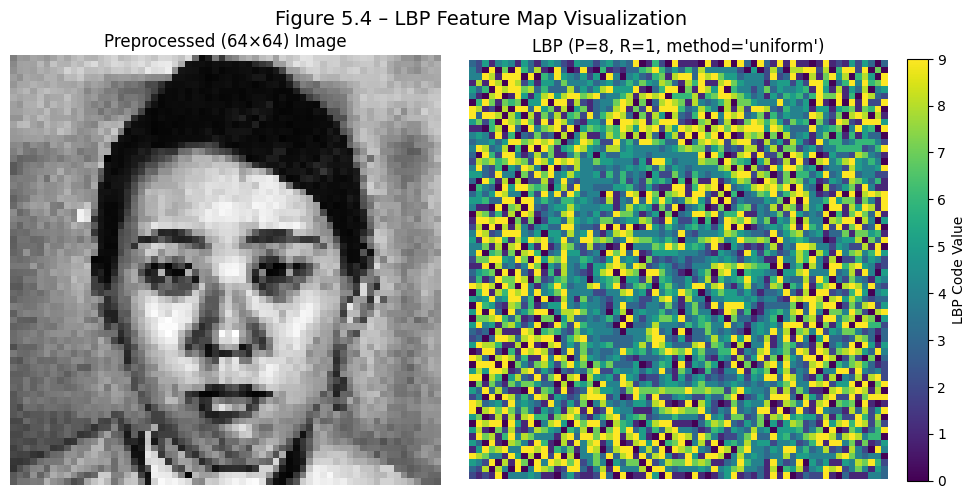

Saved LBP figure to: /content/drive/My Drive/FER_project/results/Figure_5_4_LBP_map.png


In [ ]:
# Figure 5.4 - LBP feature map visualization
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

# ---------- Paths ----------
jaffe_train = "/content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/train"
ck_candidates = [
    "/content/drive/My Drive/FER_project/data/CK",
    "/content/drive/My Drive/FER_project/data/CK+",
    "/content/drive/My Drive/FER_project/data/CK_raw",
]
results_dir = "/content/drive/My Drive/FER_project/results"
os.makedirs(results_dir, exist_ok=True)
save_path = os.path.join(results_dir, "Figure_5_4_LBP_map.png")

# ---------- Helper: find one image ----------
def find_first_image_in_dir(root_dir):
    if not os.path.isdir(root_dir):
        return None
    for root, dirs, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith(('.png','.jpg','.jpeg','.tiff','.bmp')):
                return os.path.join(root, f)
    return None

img_path = find_first_image_in_dir(jaffe_train)
if img_path is None:
    for cand in ck_candidates:
        img_path = find_first_image_in_dir(cand)
        if img_path:
            break

if img_path is None:
    raise FileNotFoundError("No sample image found in JAFFE train or CK candidate folders. Update the path.")

print("Using image:", img_path)

# ---------- Read image ----------
img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# ---------- Preprocessing ----------
# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img_gray)

# Resize to 64x64 (bicubic)
target_size = (64, 64)
img_resized = cv2.resize(img_clahe, target_size, interpolation=cv2.INTER_CUBIC)

# ---------- Compute LBP ----------
P = 8  # number of circularly symmetric neighbour set points
R = 1  # radius
METHOD = 'uniform'  # 'uniform' often used for rotation-invariant LBP histograms
lbp = local_binary_pattern(img_resized, P, R, method=METHOD)

# Normalize LBP for better visualization (optional)
lbp_norm = (lbp - lbp.min()) / (lbp.max() - lbp.min() + 1e-8)

# ---------- Plot original (resized) and LBP ----------
plt.figure(figsize=(10,5))

ax1 = plt.subplot(1,2,1)
ax1.imshow(img_resized, cmap='gray', vmin=0, vmax=255)
ax1.set_title("Preprocessed (64×64) Image")
ax1.axis('off')

ax2 = plt.subplot(1,2,2)
im = ax2.imshow(lbp, cmap='viridis')
ax2.set_title(f"LBP (P={P}, R={R}, method='{METHOD}')")
ax2.axis('off')
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('LBP Code Value')

plt.suptitle("Figure 5.4 – LBP Feature Map Visualization", fontsize=14)
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved LBP figure to:", save_path)


Using image: /content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/train/Angry/NM.AN2.105.tiff


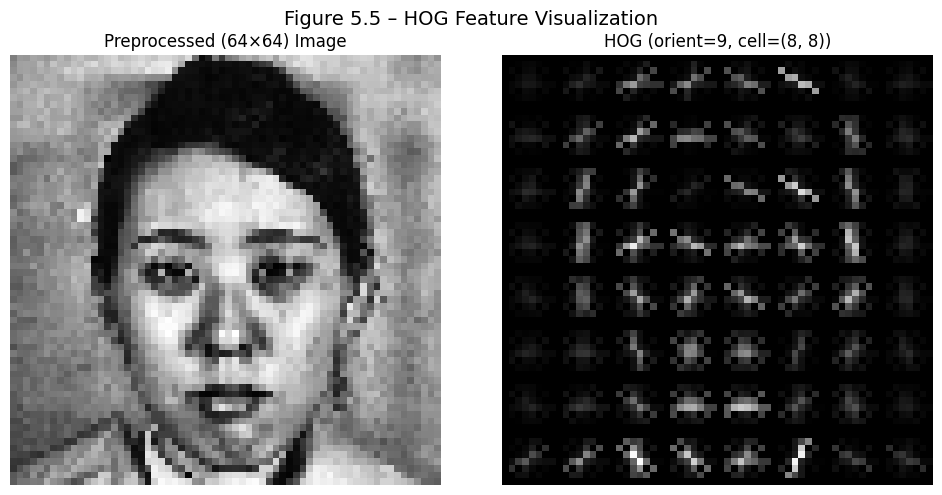

Saved HOG figure to: /content/drive/My Drive/FER_project/results/Figure_5_5_HOG_vis.png


In [ ]:
# Figure 5.5 - HOG feature visualisation
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure

# ---------- Paths ----------
jaffe_train = "/content/drive/My Drive/FER_project/data/JAFFE_raw/JAFFE/train"
ck_candidates = [
    "/content/drive/My Drive/FER_project/data/CK",
    "/content/drive/My Drive/FER_project/data/CK+",
    "/content/drive/My Drive/FER_project/data/CK_raw",
]
results_dir = "/content/drive/My Drive/FER_project/results"
os.makedirs(results_dir, exist_ok=True)
save_path = os.path.join(results_dir, "Figure_5_5_HOG_vis.png")

# ---------- Helper: find one image ----------
def find_first_image_in_dir(root_dir):
    if not os.path.isdir(root_dir):
        return None
    for root, dirs, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith(('.png','.jpg','.jpeg','.tiff','.bmp')):
                return os.path.join(root, f)
    return None

img_path = find_first_image_in_dir(jaffe_train)
if img_path is None:
    for cand in ck_candidates:
        img_path = find_first_image_in_dir(cand)
        if img_path:
            break

if img_path is None:
    raise FileNotFoundError("No sample image found in JAFFE train or CK candidate folders. Update the path.")

print("Using image:", img_path)

# ---------- Read image ----------
img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# ---------- Preprocessing ----------
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img_gray)
target_size = (64, 64)
img_resized = cv2.resize(img_clahe, target_size, interpolation=cv2.INTER_CUBIC)

# ---------- HOG parameters ----------
orientations = 9
pixels_per_cell = (8, 8)
cells_per_block = (2, 2)
visualize = True
transform_sqrt = True

# ---------- Compute HOG ----------
hog_features, hog_image = hog(
    img_resized,
    orientations=orientations,
    pixels_per_cell=pixels_per_cell,
    cells_per_block=cells_per_block,
    block_norm='L2-Hys',
    visualize=visualize,
    transform_sqrt=transform_sqrt,
    feature_vector=True
)

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, np.max(hog_image)))

# ---------- Plot ----------
plt.figure(figsize=(10,5))

ax1 = plt.subplot(1,2,1)
ax1.imshow(img_resized, cmap='gray', vmin=0, vmax=255)
ax1.set_title("Preprocessed (64×64) Image")
ax1.axis('off')

ax2 = plt.subplot(1,2,2)
ax2.imshow(hog_image_rescaled, cmap='gray')
ax2.set_title(f"HOG (orient={orientations}, cell={pixels_per_cell})")
ax2.axis('off')

plt.suptitle("Figure 5.5 – HOG Feature Visualization", fontsize=14)
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved HOG figure to:", save_path)
